# Tasks (week 8):

1. Fit Random Forest models using each possible input on its own to predict edibility. Evaluate the
quality of fit by using the predict function to calculate the predicted class for each mushroom (edible
or poisonous). Which input fits best? (i.e. which classifies the most
mushrooms correctly?) (0.5 marks)

2. Using cross-validation, perform a model selection to determine which features are useful for making
predictions using a Random Forest. As above, use the number of mushrooms correctly classified as the
criterion for deciding which model is best. You might try to find a way to loop over all 32 possible
models. Or select features ‘greedily’, by picking one at a
time to add to the model. Present your results in the most convincing way you can. (2 marks)

3. Would you use this classifier if you were foraging for mushrooms? Discuss with reference to factors that
you identified as important and the probability of poisoning yourself. (0.5 marks)

# Task 1:

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mushrooms = 'mushrooms.csv'
mushrooms_file = np.array(pd.read_csv(mushrooms, delimiter = ','))

accuracy1 = []
df = pd.DataFrame({'Safety':list(mushrooms_file[:,0]), 'Shape':list(mushrooms_file[:,1]), 'CapSurface':list(mushrooms_file[:,2]), 'CapColour':list(mushrooms_file[:,3]), 'Odor':list(mushrooms_file[:,4]), 'Height':list(mushrooms_file[:,5])})
df['Safety'], _ = pd.factorize(df['Safety'])
df['Shape'], _ = pd.factorize(df['Shape'])
df['CapSurface'], _ = pd.factorize(df['CapSurface'])
df['CapColour'], _ = pd.factorize(df['CapColour'])
df['Odor'], _ = pd.factorize(df['Odor'], use_na_sentinel=False) # For no odour, the values in the data frame were 'None', use_na_sentinel changes these to typical string values
df['Height'], _ = pd.factorize(df['Height'])
df.head()

X1 = df[['Shape']]
Y = df['Safety']
x_train1, x_test1, y_train1, y_test1 = train_test_split(X1, Y, test_size=0.2)
myforest1 = RandomForestRegressor(n_estimators=100)
forest1 = myforest1.fit(x_train1, y_train1)
prediction1 = forest1.score(x_test1, y_test1)

X2 = df[['CapSurface']]
x_train2, x_test2, y_train2, y_test2 = train_test_split(X2, Y, test_size=0.2)
myforest2 = RandomForestClassifier()
forest2 = myforest2.fit(x_train2, y_train2)
prediction2 = forest2.score(x_test2, y_test2)

X3 = df[['CapColour']]
x_train3, x_test3, y_train3, y_test3 = train_test_split(X3, Y, test_size=0.2)
myforest3 = RandomForestRegressor(n_estimators=100)
forest3 = myforest3.fit(x_train3, y_train3)
prediction3 = forest3.score(x_test3, y_test3)

X4 = df[['Odor']]
x_train4, x_test4, y_train4, y_test4 = train_test_split(X4, Y, test_size=0.2)
myforest4 = RandomForestRegressor(n_estimators=100)
forest4 = myforest4.fit(x_train4, y_train4)
prediction4 = forest4.score(x_test4, y_test4)

X5 = df[['Height']]
x_train5, x_test5, y_train5, y_test5 = train_test_split(X5, Y, test_size=0.2)
myforest5 = RandomForestRegressor(n_estimators=100)
forest5 = myforest5.fit(x_train5, y_train5)
prediction5 = forest5.score(x_test5, y_test5)

accuracy1.append(prediction1)
accuracy1.append(prediction2)
accuracy1.append(prediction3)
accuracy1.append(prediction4)
accuracy1.append(prediction5)

max_acc1 = np.max(accuracy1)
print('The most accurate single variable for finding poisonous mushrooms was Odor')
print('With an accuracy of', max_acc1)

# Odor gives the best prediction for poisonous mushrooms with an accuracy prediction that is closest to 1

The most accurate single variable for finding poisonous mushrooms was Odor
With an accuracy of 0.9520214217835596


# Task 2:

In [2]:
# Now we will combine two x variables and find the best model prediction using a greedy selection
# Odor was gave the best accuraycy for predicting poisonous mushrooms on its own so we will select one more to add to odor

combinations = [['Shape', 'Odor'], ['CapSurface', 'Odor'], ['CapColour', 'Odor'], ['Height', 'Odor']]
mean_score_list1 = []
def mean_score_RF(combination):
    x_train, x_test, y_train, y_test = train_test_split(df[combination], Y, test_size=0.2)
    score = cross_val_score(RandomForestRegressor(n_estimators=100), x_train, y_train, cv=5)
    mean = sum(score) / len(score)
    return mean

SO_mean = mean_score_RF(combinations[0])
mean_score_list1.append(SO_mean)

CsO_mean = mean_score_RF(combinations[1])
mean_score_list1.append(CsO_mean)

CcO_mean = mean_score_RF(combinations[2])
mean_score_list1.append(CcO_mean)

HO_mean = mean_score_RF(combinations[3])
mean_score_list1.append(HO_mean)

max_score1 = np.max(mean_score_list1)
max_index1 = np.argmax(mean_score_list1)
best_combo1 = combinations[max_index1]

print('The two variables that gave the best accuracy through cross validation are:', best_combo1)
print('With a mean accuracy of', max_score1)
print('')


mean_score_list2 = []
combinations2 = [['CapColour', 'CapSurface', 'Odor'], ['CapColour', 'Height', 'Odor'], ['CapColour', 'Shape', 'Odor'], 
                 ['Shape', 'CapSurface', 'Odor'], ['Shape', 'Odor', 'Height'], ['CapSurface', 'Odor', 'Height']]
CcCsO_mean = mean_score_RF(combinations2[0])
mean_score_list2.append(CcCsO_mean)

CcHO_mean = mean_score_RF(combinations2[1])
mean_score_list2.append(CcHO_mean)

CcSO_mean = mean_score_RF(combinations2[2])
mean_score_list2.append(CcSO_mean)

SCsO_mean = mean_score_RF(combinations2[3])
mean_score_list2.append(SCsO_mean)

SOH_mean = mean_score_RF(combinations2[4])
mean_score_list2.append(SOH_mean)

CsOH_mean = mean_score_RF(combinations2[5])
mean_score_list2.append(CsOH_mean)

max_score2 = np.max(mean_score_list2)
max_index2 = np.argmax(mean_score_list2)
best_combo2 = combinations2[max_index2]
print('The three variables that gave the best accuracy through cross validation are:', best_combo2)
print('With a mean accuracy of', max_score2)
print('')


mean_score_list3 = []
combinations3 = [['CapColour', 'Shape', 'Odor', 'Height'], ['CapColour', 'Shape', 'Odor', 'CapSurface'], 
                 ['CapColour', 'Height', 'Odor', 'CapSurface'], ['Shape', 'CapSurface', 'Odor', 'Height']]
CcCsOH_mean = mean_score_RF(combinations3[0])
mean_score_list3.append(CcCsOH_mean)

CcSOCs_mean = mean_score_RF(combinations3[1])
mean_score_list3.append(CcSOCs_mean)

CcHOCs_mean = mean_score_RF(combinations3[2])
mean_score_list3.append(CcHOCs_mean)

SCsOH_mean = mean_score_RF(combinations3[3])
mean_score_list3.append(SCsOH_mean)

max_score3 = np.max(mean_score_list3)
max_index3 = np.argmax(mean_score_list3)
best_combo3 = combinations3[max_index3]
print('The three variables that gave the best accuracy through cross validation are:', best_combo3)
print('With a mean accuracy of', max_score3)
print('')


combinations4 = ['CapColour', 'Shape', 'Odor', 'Height', 'CapColour']
all_inputs_mean = mean_score_RF(combinations4)
print('Through cross validation the accuracy using all available inputs was:', all_inputs_mean)

The two variables that gave the best accuracy through cross validation are: ['CapColour', 'Odor']
With a mean accuracy of 0.9587414867066464

The three variables that gave the best accuracy through cross validation are: ['CapColour', 'Shape', 'Odor']
With a mean accuracy of 0.9714836184229526

The three variables that gave the best accuracy through cross validation are: ['CapColour', 'Shape', 'Odor', 'CapSurface']
With a mean accuracy of 0.9770965345612161

Through cross validation the accuracy using all available inputs was: 0.9728815368347652


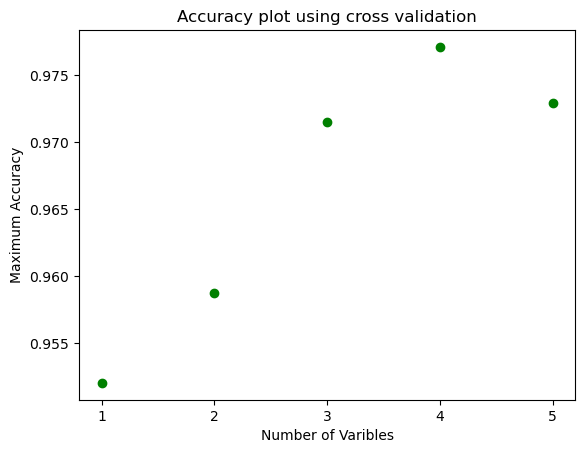

In [3]:
max_accs = []
max_accs.append(max_acc1)
max_accs.append(max_score1)
max_accs.append(max_score2)
max_accs.append(max_score3)
max_accs.append(all_inputs_mean)
number_of_variables = np.arange(1,6,1)

plt.scatter(number_of_variables, max_accs, color='g')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Number of Varibles')
plt.ylabel('Maximum Accuracy')
plt.title('Accuracy plot using cross validation')
plt.show()

# Task 3:

The random forest algorith is useful to deterine the safety of mushrooms, it consistently classifies odor as the most accurate variable for determining poisonous mushrooms, and also consistently reproduces the combination accuracy of the other variables like ['CapColour', 'Odor'], ['CapColour', 'Shape', 'Odor'] and ['CapColour', 'Shape', 'Odor', 'CapSurface'] as the next three most accurate variable combinations.

# Tasks (week 9):

4. Fit an ANN model using each possible input on its own to predict edibility.
Evaluate the
quality of fit by using the predict function to calculate the predicted class for each mushroom (edible
or poisonous). Which input fits best? (i.e. which classifies the most
mushrooms correctly?) (0.5 marks)

5. Using cross-validation, perform a model selection to determine which features are useful for making
predictions using the ANN. As above, use the number of mushrooms correctly classified as the
criterion for deciding which model is best. You might try to find a way to loop over all 32 possible
models. Or select features ‘greedily’, by picking one at a
time to add to the model. Present your results in the most convincing way you can. (2 marks)

6. Take the best model and explore how the performance depends on the architecture of the ANN.
Vary the number and the sizes of the hidden layers. For large networks you may want to increase the number of the stochastic gradient descent iterations. (1 mark)

7. Compare the performance of Random Forest and ANN models.
For example, which data types, do you think, the two ML models are most suited to describe.  (0.5 marks)

8. Quality of presentation of report in Jupyter notebook (2 mark)

9. Bonus point: Justify why your work/report goes beyond just completing the tasks and deserves an extra mark (1 mark) 

# Task 4:

In [4]:
accuracy2 = []
neural_network = MLPClassifier(solver='sgd', learning_rate_init=0.1, 
                               hidden_layer_sizes=(50,), max_iter=20000, random_state=4)

neural_network.fit(x_train1, y_train1)
y_pred1 = neural_network.predict(x_test1)
ANN_acc1 = accuracy_score(y_test1, y_pred1)

neural_network.fit(x_train2, y_train2)
y_pred2 = neural_network.predict(x_test2)
ANN_acc2 = accuracy_score(y_test2, y_pred2)

neural_network.fit(x_train3, y_train3)
y_pred3 = neural_network.predict(x_test3)
ANN_acc3 = accuracy_score(y_test3, y_pred3)

neural_network.fit(x_train4, y_train4)
y_pred4 = neural_network.predict(x_test4)
ANN_acc4 = accuracy_score(y_test4, y_pred4)

neural_network.fit(x_train5, y_train5)
y_pred5 = neural_network.predict(x_test5)
ANN_acc5 = accuracy_score(y_test5, y_pred5)

accuracy2.append(prediction1)
accuracy2.append(prediction2)
accuracy2.append(prediction3)
accuracy2.append(prediction4)
accuracy2.append(prediction5)

ANN_acc = np.max(accuracy2)
print('The most accurate single variable for finding poisonous mushrooms was Odor')
print('With an accuracy of', ANN_acc)

The most accurate single variable for finding poisonous mushrooms was Odor
With an accuracy of 0.9520214217835596


# Task 5:

In [5]:
# Using greedy selection, we will assess whether the ANN predictions match the random forest predictions

def mean_score_ANN(combination):
    x_train_, x_test_, y_train_, y_test_ = train_test_split(df[combination], Y, test_size=0.1)
    score = cross_val_score(neural_network, x_train_, y_train_, cv=5)
    mean = sum(score) / len(score)
    return mean
CV_O_mean_ANN = mean_score_ANN(['Odor'])
print('Through cross validation, variable that gave the best accuracy through artificial neural networks was odor')
print('With a mean accuracy of', CV_O_mean_ANN)
print('')

mean_score_list5 = []
SO_mean_ANN = mean_score_ANN(combinations[0])
mean_score_list5.append(SO_mean_ANN)

CsO_mean_ANN = mean_score_ANN(combinations[1])
mean_score_list5.append(CsO_mean_ANN)

CcO_mean_ANN = mean_score_ANN(combinations[2])
mean_score_list5.append(CcO_mean_ANN)

HO_mean_ANN = mean_score_ANN(combinations[3])
mean_score_list5.append(HO_mean_ANN)

max_score5 = np.max(mean_score_list5)
max_index5 = np.argmax(mean_score_list5)
best_combo5 = combinations[max_index5]
print('Through cross validation, the two variables that gave the best accuracy through artificial neural networks are:', best_combo1)
print('With a mean accuracy of', max_score5)
print('')


mean_score_list6 = []
CcCsO_mean_ANN = mean_score_ANN(combinations2[0])
mean_score_list6.append(CcCsO_mean_ANN)

CcHO_mean_ANN = mean_score_ANN(combinations2[1])
mean_score_list6.append(CcHO_mean_ANN)

CcSO_mean_ANN = mean_score_ANN(combinations2[2])
mean_score_list6.append(CcSO_mean_ANN)

SCsO_mean_ANN = mean_score_ANN(combinations2[3])
mean_score_list6.append(SCsO_mean_ANN)

SOH_mean_ANN = mean_score_ANN(combinations2[4])
mean_score_list6.append(SOH_mean_ANN)

CsOH_mean_ANN = mean_score_ANN(combinations2[5])
mean_score_list6.append(CsOH_mean_ANN)

max_score6 = np.max(mean_score_list6)
max_index6 = np.argmax(mean_score_list6)
best_combo6 = combinations2[max_index6]
print('Through cross validation, the two variables that gave the best accuracy through artificial neural networks are', best_combo6)
print('With a mean accuracy of', max_score6)
print('')


mean_score_list7 = []
CcCsOH_mean_ANN = mean_score_ANN(combinations3[0])
mean_score_list7.append(CcCsOH_mean_ANN)

CcSOCs_mean_ANN = mean_score_ANN(combinations3[1])
mean_score_list7.append(CcSOCs_mean_ANN)

CcHOCs_mean_ANN = mean_score_ANN(combinations3[2])
mean_score_list7.append(CcHOCs_mean_ANN)

SCsOH_mean_ANN = mean_score_ANN(combinations3[3])
mean_score_list7.append(SCsOH_mean_ANN)

max_score7 = np.max(mean_score_list7)
max_index7 = np.argmax(mean_score_list7)
best_combo7 = combinations3[max_index7]
print('Through cross validation, the two variables that gave the best accuracy through artificial neural networks are:', best_combo7)
print('With a mean accuracy of', max_score7)
print('')


all_inputs_mean_ANN = mean_score_ANN(combinations4)
print('Through cross validation, and the use of an artificial neural network the accuracy using all available inputs was:', all_inputs_mean_ANN)
print('')

Through cross validation, variable that gave the best accuracy through artificial neural networks was odor
With a mean accuracy of 0.9856377045087535

Through cross validation, the two variables that gave the best accuracy through artificial neural networks are: ['CapColour', 'Odor']
With a mean accuracy of 0.9864591524826242

Through cross validation, the two variables that gave the best accuracy through artificial neural networks are ['Shape', 'CapSurface', 'Odor']
With a mean accuracy of 0.9887837053147731

Through cross validation, the two variables that gave the best accuracy through artificial neural networks are: ['CapColour', 'Shape', 'Odor', 'CapSurface']
With a mean accuracy of 0.9905620910876868

Through cross validation, and the use of an artificial neural network the accuracy using all available inputs was: 0.9874154357414492



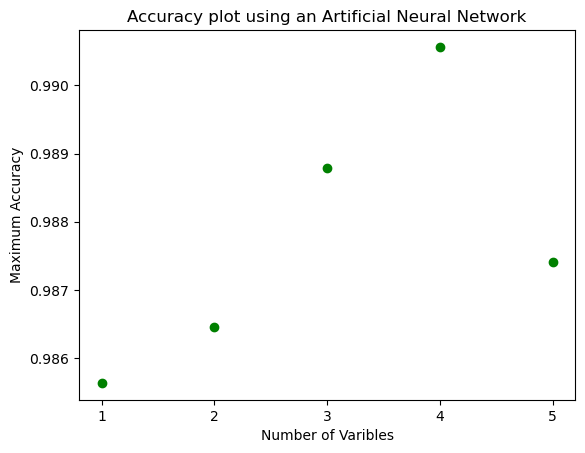

In [6]:
max_accs_ANN = []
max_accs_ANN.append(CV_O_mean_ANN)
max_accs_ANN.append(max_score5)
max_accs_ANN.append(max_score6)
max_accs_ANN.append(max_score7)
max_accs_ANN.append(all_inputs_mean_ANN)

plt.scatter(number_of_variables, max_accs_ANN, color='g')
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel('Number of Varibles')
plt.ylabel('Maximum Accuracy')
plt.title('Accuracy plot using an Artificial Neural Network')
plt.show()

# Task 6:

In [7]:
hidden_layers = [(1,), (2,), (3,), (4,), (5,), (6,), (7,), (8,), (9,)]
mean_scores_hidden_lays = []
for i in hidden_layers:
    neural_network2 = MLPClassifier(solver='sgd', learning_rate_init=0.2, 
                                   hidden_layer_sizes=i, max_iter=20000, random_state=4)
    score_hl = cross_val_score(neural_network2, x_train4, y_train4, cv=7)
    mean_hl = sum(score_hl) / len(score_hl)
    mean_scores_hidden_lays.append(mean_hl)
    
print(np.array(mean_scores_hidden_lays))

[0.51299964 0.98461271 0.60289714 0.98461271 0.9576815  0.67510486
 0.98461271 0.79693987 0.67308424]


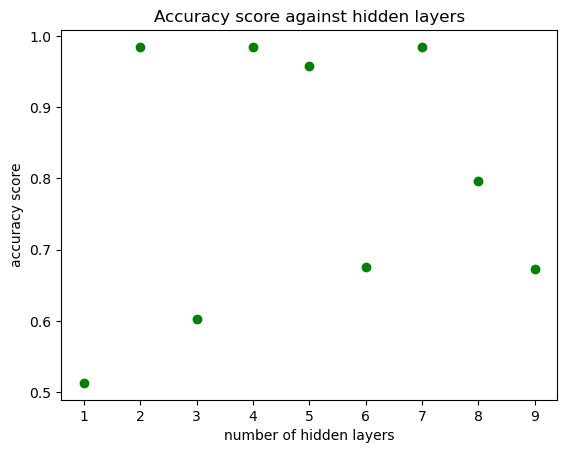

In [8]:
x_lay_size = np.array(hidden_layers)
plt.scatter(x_lay_size, mean_scores_hidden_lays, color='green')
plt.xlabel('number of hidden layers')
plt.ylabel('accuracy score')
plt.title('Accuracy score against hidden layers')
plt.show()

Overall the accuracy increases with increase in hidden layer number, at low number of hidden layers, and when the hidden layers are even the accuracy also consistently seems to be higher. 

# Task 7:

Both the random forest and artificial neural network had similar predictions on how the number of variables affected the overall accuracy of the reults. While the ANN produced overall higher accuracy for the given number of variables, the random forest gave quicker and more consistent results.

The ANN is better used for smaller data sets where there aren't as many variables, for these data sets we can tune the parameters of the ANN to learn from a smaller set of information. The random forest is more efficient when handling larger data sets, where there is an abundance of information.

Overall the accuracy of the ANN was limited by the speed of the programme, when using large numbers of hidden layers and a slower learning rate the ANN is more accurate but runs far more slowly with such large data.

# Task 9:

My code shows that both machine learning approaches predict the edibility of mushrooms with consistent accuracy. The two plots show where the accuracy peaks around 3 and 4 variables, with more consistency in the random forest method, but overall better accuracy with the ANN.

For the ANN and the RF methods I also show what variables are most succesful for each iteration, again the consistency of the RF proved to be better showing the same combination of variables for the most accurate predictions, where the ANN varied slightly in its predictions.

# Self-Assessment

I tested the different inputs for MLPClassifier() in my ANN to find the best combination of speed and accuracy in my results, overall the number of hidden layers needed to be kept low enough to keep the programme running quickly but not so that my results would become inconsistent.

My plots show how the accuracy varies with number of variables and how the accuracy is affected when we change the inputs to MLPClassifier().

Cross validation was succesful in predicting the most useful variables for predicting the edibility of mushrooms where cross_val_score() was used to etermine the accuracy of my predicted data.